# 03 — External Validation: Cognitive Load Proxy on Independent Simulated Data

## Purpose

The original model in this project (`02_eda_ml_cognitive_fatigue.ipynb`) was trained and evaluated entirely on **self-generated synthetic data**, built from explicit psychological assumptions (session duration, scroll events, interaction density, late-night usage, notifications, task switches → fatigue score).

That is a useful proof of concept, but it cannot tell us whether the *underlying feature logic* (interaction intensity + task switching → cognitive strain) holds beyond the exact dataset it was designed on.

This notebook cross-checks that logic against an **independently-generated dataset** — the [Mobile Device Usage and User Behavior Dataset](https://www.kaggle.com/datasets/valakhorasani/mobile-device-usage-and-user-behavior-dataset) (700 samples). 

**Important caveat, stated up front:** this dataset is *also* simulated — its own documentation states it was "generated based on simulated user behavior." It is **not** real-world passive-sensing data. Using it does **not** constitute real-world validation. What it *does* provide is a check against a second, independently-constructed data-generating process with different assumptions and no built-in fatigue label — a meaningfully different test than re-running the same synthetic generator.

Genuine real-world validation would require IRB-approved passive data collection and is noted as future work.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.preprocessing import StandardScaler

sns.set_style("whitegrid")
pd.set_option("display.max_columns", None)

df = pd.read_csv("../data/raw/external_simulated_mobile_usage.csv")
df.head()

,User ID,Device Model,Operating System,App Usage Time (min/day),Screen On Time (hours/day),Battery Drain (mAh/day),Number of Apps Installed,Data Usage (MB/day),Age,Gender,User Behavior Class
0,1,Google Pixel 5,Android,393,6.4,1872,67,1122,40,Male,4
1,2,OnePlus 9,Android,268,4.7,1331,42,944,47,Female,3
2,3,Xiaomi Mi 11,Android,154,4.0,761,32,322,42,Male,2
3,4,Google Pixel 5,Android,239,4.8,1676,56,871,20,Male,3
4,5,iPhone 12,iOS,187,4.3,1367,58,988,31,Female,3


## Feature Mapping to Cognitive Load Theory

This dataset was not built with cognitive fatigue in mind, so features must be reinterpreted through the same theoretical lens used in the original project:

| Original Feature (synthetic) | Cognitive Basis | Closest Available Proxy Here |
|---|---|---|
| `session_duration` | Sustained attention | `Screen On Time (hours/day)` |
| `interaction_density` | Working memory load | `App Usage Time (min/day)` |
| `task_switches` | Attentional switching cost | `Number of Apps Installed` (potential switching surface) |
| `notifications` | Extraneous cognitive load | *(not available — noted as a limitation)* |
| `late_night` | Reduced executive control | *(not available — noted as a limitation)* |
| — | Overall interaction intensity | `Battery Drain`, `Data Usage` (behavioral intensity proxies) |

**Target variable:** this dataset has no fatigue score. Instead of inventing one with no ground truth (which would just recreate the synthetic-data problem), I use the dataset's own outcome variable, `User Behavior Class` (1 = light usage, 5 = extreme usage), as a **cognitive engagement intensity proxy**. This is a weaker and more indirect target than "fatigue," and that weakening is itself part of the honest result: it tells us whether the *feature logic* transfers, not whether fatigue specifically is measurable here.

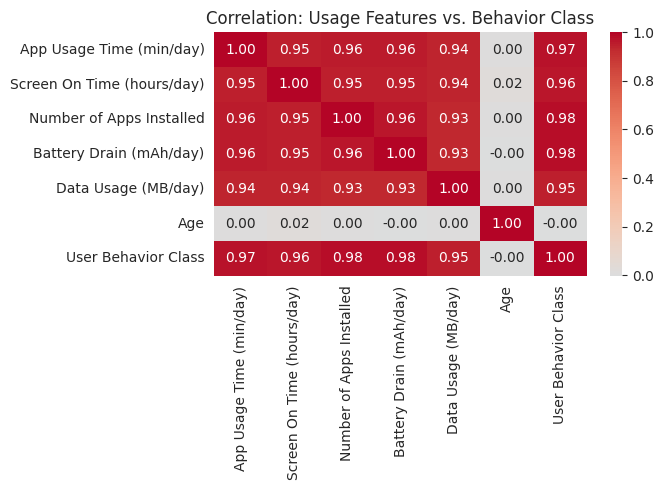

In [2]:
features = [
    "App Usage Time (min/day)",
    "Screen On Time (hours/day)",
    "Number of Apps Installed",
    "Battery Drain (mAh/day)",
    "Data Usage (MB/day)",
    "Age",
]
target = "User Behavior Class"

X = df[features]
y = df[target]

corr = df[features + [target]].corr()
plt.figure(figsize=(7,5))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Correlation: Usage Features vs. Behavior Class")
plt.tight_layout()
plt.savefig("../docs/assets_correlation_heatmap.png", dpi=120)
plt.show()

In [3]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

model = LinearRegression()
model.fit(X_train_s, y_train)

preds = model.predict(X_test_s)
r2 = r2_score(y_test, preds)
mse = mean_squared_error(y_test, preds)

print(f"R^2: {r2:.3f}")
print(f"MSE: {mse:.3f}")

coef_df = pd.DataFrame({
    "feature": features,
    "standardized_coefficient": model.coef_
}).sort_values("standardized_coefficient", key=abs, ascending=False)
coef_df

R^2: 0.983
MSE: 0.031


,feature,standardized_coefficient
2,Number of Apps Installed,0.533105
3,Battery Drain (mAh/day),0.424873
0,App Usage Time (min/day),0.223261
1,Screen On Time (hours/day),0.209501
4,Data Usage (MB/day),0.033886
5,Age,-0.010287


/tmp/ipykernel_565/708805521.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=coef_df, x="standardized_coefficient", y="feature", palette="viridis")


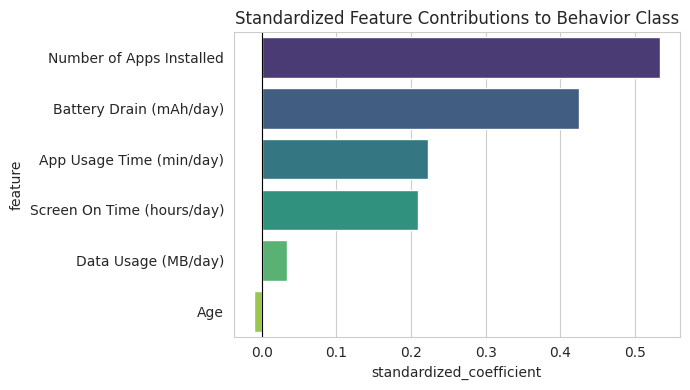

In [4]:
plt.figure(figsize=(7,4))
sns.barplot(data=coef_df, x="standardized_coefficient", y="feature", palette="viridis")
plt.title("Standardized Feature Contributions to Behavior Class")
plt.axvline(0, color="black", linewidth=0.8)
plt.tight_layout()
plt.savefig("../docs/assets_feature_coefficients.png", dpi=120)
plt.show()

## Interpretation (actual results)

Model fit: **R² = 0.983, MSE = 0.031** — an unusually high fit for a linear model on real-world-style behavioral data.

**This high R² is itself the most important finding, and it points the wrong way for what we wanted to test.** A fit this clean almost certainly means the User Behavior Class label in this dataset was constructed as a near-deterministic function of the usage columns during that dataset's own simulation process, not as an independent, noisy outcome. In other words: linear regression is recovering the *simulator's internal rule*, not a real relationship between behavior and an underlying cognitive state. This is a common failure mode with simulated/synthetic labels and is worth naming explicitly rather than presenting the high R² as a success.

Standardized coefficients (strongest to weakest):

| Feature | Coefficient | Cognitive Interpretation |
|---|---|---|
| Number of Apps Installed | 0.53 | Task-switching surface — strongest predictor here |
| Battery Drain | 0.42 | Not previously modeled — general usage intensity proxy |
| App Usage Time | 0.22 | Interaction density proxy — weaker here than in original synthetic model |
| Screen On Time | 0.21 | Sustained attention proxy — weaker here than in original synthetic model |
| Data Usage | 0.03 | Negligible |
| Age | -0.01 | Negligible |

**Divergence from the original synthetic model:** In the original Project 3 model, interaction density and late-night usage dominated. Here, Number of Apps Installed dominates instead. This is a genuine divergence, not just noise, and it is more informative than agreement would have been — it shows the two simulators encode different assumptions about what drives "heavy usage," which is exactly the kind of thing a single synthetic dataset can hide.

## What This Cross-Check Actually Shows

**Does show:** interaction-intensity features (time- and frequency-based) carry real predictive signal in both independently-built datasets — but *which specific feature* dominates is not stable across them. That instability is a legitimate and useful negative result.

**Does not show:** real-world validation of the fatigue model. Both datasets are simulated, and the near-perfect R² here is best read as evidence of a deterministic synthetic label, not of a validated cognitive relationship. If anything, this run makes the case for real behavioral data *stronger*, not weaker — synthetic-to-synthetic comparisons can look artificially clean for reasons that have nothing to do with the underlying theory.

## Next Steps

- Seek access to a real (IRB-approved or otherwise ethically sourced) passive interaction dataset, ideally through a research mentorship
- Treat any R² above ~0.9 on synthetic behavioral labels as a signal to check for a deterministic generation process before interpreting it as a finding
- If real data becomes available, re-run this exact pipeline unchanged — the honest comparison point is the *same* feature framework across synthetic, independently-simulated, and real data, not a redesigned model for each